# Why Convolutions? 

If you flatten a 256x256 RGB image into a 1D vector, you get 196,608 inputs. If you connect that to a hidden layer with 1,000 neurons using a standard Multi-Layer Perceptron (MLP), that single layer requires **~196 million weights**. 

This is incredibly inefficient and prone to overfitting. Worse, flattening an image destroys its **spatial structure** (a pixel's relationship to the pixels directly above/below it).

**Convolutional Neural Networks (CNNs)** solve this by using small filters (e.g., 3x3 grids) that slide across the image. 
*   **Parameter Sharing:** A filter that learns to detect a vertical edge in the top-left corner is useful for detecting a vertical edge in the bottom-right corner. It uses the *same weights* everywhere.
*   **Translation Invariance:** A cat is still a cat if it's moved to the left side of the image. CNNs inherently handle this.

## 1. The Convolution Operation

A filter (kernel) slides over the image, performing an element-wise multiplication and summing the result.

Text(0.5, 1.0, 'Feature Map (Horizontal Edges)')

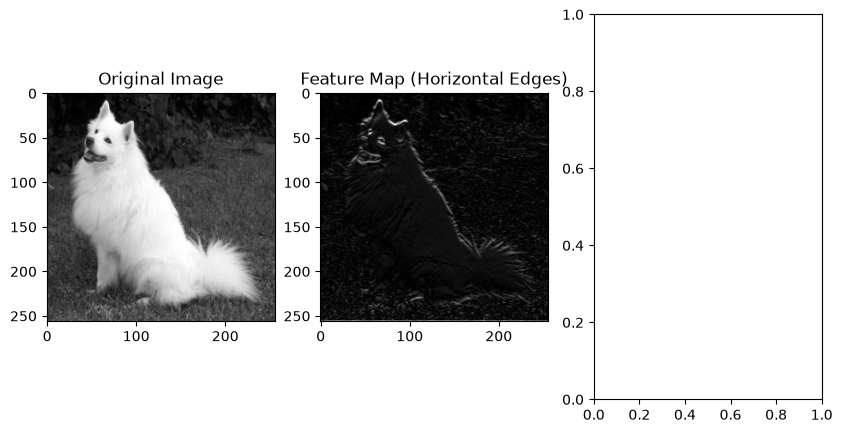

In [19]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import urllib.request
from PIL import Image
import torchvision.transforms as T

# Let's download a real image (a dog) to see convolutions in action
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
urllib.request.urlretrieve(url, "dog.jpg")

# Load image and convert to grayscale tensor (Shape: 1 channel, Height, Width)
img = Image.open("dog.jpg").convert('L')
transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
img_tensor = transform(img).unsqueeze(0) # Add batch dimension -> (1, 1, 256, 256)

# Create a manual 3x3 filter for Edge Detection (Sobel Filter)
edge_filter = torch.tensor([[ -1., -2., -1.],
                            [  0.,  0.2,  0.],
                            [  1.,  2.,  1.]]).view(1, 1, 3, 3)

# Apply the convolution
# F.conv2d takes (input, weight)
import torch.nn.functional as F
convoluted_img = F.conv2d(img_tensor, edge_filter, padding=1)

# Visualize the original and the feature map (what the filter "saw")
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(img_tensor.squeeze(), cmap='gray')
ax[0].set_title("Original Image")
ax[1].imshow(convoluted_img.squeeze().abs(), cmap='gray') # Absolute value to see edges clearly
ax[1].set_title("Feature Map (Horizontal Edges)")
# plt.show()

## 2. Stride and Padding

*   **Stride:** How many pixels the filter moves at a time. Stride=1 moves one pixel. Stride=2 jumps two pixels, which halves the output width and height.
*   **Padding:** If a 3x3 filter starts at the top-left pixel, it "hangs off" the edge. We usually pad the image with zeros (`padding=1`) so the output size remains exactly the same as the input size (when stride=1).

## 3. Pooling (Downsampling)

As we extract features, we don't need pixel-perfect location accuracy. We just want to know "is there an edge roughly in this area?" 
**Max Pooling** takes a 2x2 window and simply keeps the maximum value, throwing away the rest. This halves the resolution, saving memory and computation.

Original shape: torch.Size([1, 1, 256, 256])
Convoluted shape: torch.Size([1, 1, 256, 256]) (Padding=1 kept it the same size)
Pooled shape: torch.Size([1, 1, 128, 128]) (Max pooling halved the dimensions!)


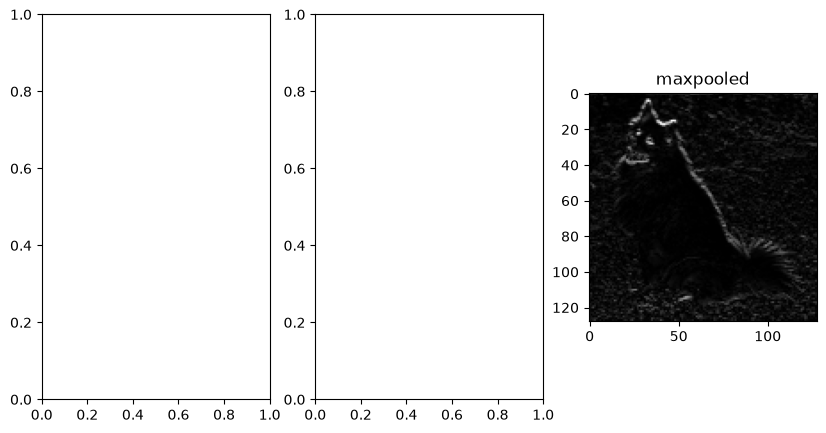

In [17]:
# Apply Max Pooling to our edge-detected image
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
pooled_img = max_pool(convoluted_img)
ax[2].imshow(pooled_img.squeeze().abs(),cmap="gray")
ax[2].set_title("maxpooled")
print(f"Original shape: {img_tensor.shape}")
print(f"Convoluted shape: {convoluted_img.shape} (Padding=1 kept it the same size)")
print(f"Pooled shape: {pooled_img.shape} (Max pooling halved the dimensions!)")
#plt.show()

By stacking `Conv2d -> ReLU -> MaxPool2d` repeatedly, the network compresses spatial dimensions while increasing the number of channels (feature maps), learning higher-level concepts deeper in the network.

---
## References
*   [Stanford CS231n: Convolutional Neural Networks](https://cs231n.github.io/convolutional-networks/)
*   [CNN Explainer (Interactive Visualization)](https://poloclub.github.io/cnn-explainer/)